In [15]:
import pandas as pd
vol_csv = pd.read_csv('VOLUME_DATASET.csv')
print(vol_csv.head())

   Unnamed: 0  OBJECTID          X          Y           LATIN_NAME  \
0         130  26609482  358778.42  173631.65       Betula pendula   
1         131  26609483  358769.66  173620.75        Betula utilis   
2         391  26609746  359249.26  173476.59  Acer platanoides cv   
3         392  26609747  359262.25  173477.53  Acer platanoides cv   
4         393  26609748  359276.98  173478.16  Acer platanoides cv   

    COMMON_NAME       FULL_COMMON_NAME         TREE_SPECIES   DBH tree_group  \
0  Silver Birch           Silver birch       Betula pendula  0.06  deciduous   
1         Birch        Himalayan birch        Betula utilis  0.32  deciduous   
2         Maple  Norway maple cultivar  Acer platanoides cv  0.50  deciduous   
3         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   
4         Maple  Norway maple cultivar  Acer platanoides cv  0.40  deciduous   

   CROWN_AREA_COMPLETE  CROWN_VOLUME  
0             3.593897      8.579590  
1            10.0000

In [ ]:
df_sensor = pd.read_csv('..\site_outputs\site_203.csv')
print(df_sensor)

        SITE_ID            LOCATION  EASTING  NORTHING            DATE_TIME  \
0           203   Brislington Depot   361178    171566  2023-01-01 00:00:00   
1           203   Brislington Depot   361178    171566  2023-01-01 01:00:00   
2           203   Brislington Depot   361178    171566  2023-01-01 02:00:00   
3           203   Brislington Depot   361178    171566  2023-01-01 03:00:00   
4           203   Brislington Depot   361178    171566  2023-01-01 04:00:00   
...         ...                 ...      ...       ...                  ...   
139971      672  Marlborough Street   358728    173520  2024-12-31 20:00:00   
139972      672  Marlborough Street   358728    173520  2024-12-31 21:00:00   
139973      672  Marlborough Street   358728    173520  2024-12-31 22:00:00   
139974      672  Marlborough Street   358728    173520  2024-12-31 23:00:00   
139975      672  Marlborough Street   358728    173520  2024-12-31 00:00:00   

         NO   NOX   NO2 PM2_5 PM10        DATE_TIME

C:\Users\andre\AppData\Local\Temp\ipykernel_47260\2522231001.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sensor = pd.read_csv('..\Traffic Data\continuous_air_quality_2324.csv')


In [38]:
import numpy as np

# Define your sensor location and the radius
SENSOR_X = 361178  # Replace with your sensor's Easting
SENSOR_Y = 171566  # Replace with your sensor's Northing
radius = 300.0       # meters

# Calculate the Euclidean distance for all rows simultaneously (vectorized for speed)
distances = np.sqrt((vol_csv['X'] - SENSOR_X)**2 + (vol_csv['Y'] - SENSOR_Y)**2)

# Filter the dataframe to only include trees within the radius
nearby_trees = vol_csv[distances <= radius].copy()

# Add the calculated distance as a new column
nearby_trees['DISTANCE_TO_SENSOR'] = distances[distances <= radius]

print(f"Found {len(nearby_trees)} trees within {radius}m of the sensor.")
# print(nearby_trees.head())

nearby_trees.to_csv('SENSOR_ID_203.csv')

Found 111 trees within 300.0m of the sensor.


In [18]:
print(nearby_trees)

      Unnamed: 0  OBJECTID          X          Y             LATIN_NAME  \
26          1559  26610931  361162.02  171571.83    Ulmus 'New Horizon'   
27          1560  26610932  361173.40  171565.53    Ulmus 'New Horizon'   
257         8362  26617862  361387.16  171550.54       Carpinus betulus   
972        41167  26650958  361175.90  171349.97  Platanus x acerifolia   
973        41168  26650959  361181.33  171355.10       Acer platanoides   
...          ...       ...        ...        ...                    ...   
1075       41338  26651129  361187.06  171388.23          Ginkgo biloba   
1076       41339  26651130  361013.09  171456.20       Parrotia persica   
1077       41397  26651188  361065.99  171351.38          Juglans regia   
1078       41398  26651189  361040.75  171319.91          Juglans regia   
1079       41399  26651190  361083.19  171373.37          Juglans regia   

     COMMON_NAME    FULL_COMMON_NAME           TREE_SPECIES       DBH  \
26           Elm  Elm ' Ne

In [39]:
df_wind = pd.read_csv('../Wind Data/clean_2023 (1).csv')
wind_subset = df_wind[['mean_wind_speed', 'mean_wind_dir']]

print(df_wind)

              ob_end_time  mean_wind_speed  mean_wind_dir  wind_to_dir  \
0     2023-01-01 00:00:00             11.0          210.0         30.0   
1     2023-01-01 01:00:00             11.0          210.0         30.0   
2     2023-01-01 02:00:00             10.0          210.0         30.0   
3     2023-01-01 03:00:00              9.0          200.0         20.0   
4     2023-01-01 04:00:00              8.0          190.0         10.0   
...                   ...              ...            ...          ...   
8746  2023-12-31 19:00:00             19.0          240.0         60.0   
8747  2023-12-31 20:00:00             20.0          240.0         60.0   
8748  2023-12-31 21:00:00             19.0          240.0         60.0   
8749  2023-12-31 22:00:00             19.0          240.0         60.0   
8750  2023-12-31 23:00:00             18.0          240.0         60.0   

     wind_to_sector  
0                NE  
1                NE  
2                NE  
3                 N  
4

In [ ]:
import pandas as pd
import numpy as np

def calculate_sensor_geometric_sink(sensor_x, sensor_y, tree_df, U, wind_dir_deg, T_max=900, D=0.2, max_distance=300):
    """
    Calculates the total Geometric Sink Factor (G_h) at a specific sensor for one hour.
    
    Parameters:
    - sensor_x, sensor_y : Coordinates of the NOx sensor.
    - tree_df            : Pandas DataFrame containing nearby trees (must have X, Y, 
                           CROWN_AREA_COMPLETE, and CROWN_VOLUME columns).
    - U, wind_dir_deg    : Hourly wind speed (m/s) and direction (degrees).
    - T_max              : Stagnation residence time (default 900s / 15 mins).
    - D                  : Diffusion rate / Minimum turbulence (default 0.2 m/s).
    - max_distance       : Cutoff distance to stop calculating blown-away puffs.
    """
    # 1. Wind Vectors
    theta = np.radians(wind_dir_deg)
    u_wind = U * np.cos(theta)
    v_wind = U * np.sin(theta)
    
    # 2. Dynamic Time-Stepping (Continuity Fix)
    dt = 1.0
    if U > 1.0:
        dt = 1.0 / U
        
    # 3. Dynamic T_max (Culled at map edge)
    dynamic_T_max = T_max
    if U > 0.1:
        time_to_cross_map = max_distance / U
        dynamic_T_max = min(T_max, time_to_cross_map)
        
    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    G_total = 0.0
    
    # 4. Fast DataFrame Iteration
    # itertuples() is much faster than iterrows() for large datasets
    for row in tree_df.itertuples(index=False):
        # Extract pre-processed data
        tx = row.X
        ty = row.Y

        ##### here we would apply the sun and seasonality multiplier which are to be defined outside script
        area = row.CROWN_AREA_COMPLETE
        vol = row.CROWN_VOLUME
        
        # Calculate precise canopy footprint radius and standard deviation
        radius = np.sqrt(area / np.pi)
        sigma_0 = radius / 2.15
        
        # Vectorized Kinematics
        puff_x = tx + (u_wind * t_array)
        puff_y = ty + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)
        
        # Squared distance from the SENSOR to every puff
        dist_sq = (sensor_x - puff_x)**2 + (sensor_y - puff_y)**2
        
        # Mass Conserved Gaussian Integration
        coeff = (vol * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))
        
        # Sum all puffs for this tree, add to the sensor's total
        G_total += np.sum(coeff * exponent)
        
    return G_total

# ==========================================
# Example: Running your MLR Data Preparation
# ==========================================

# # 1. Load your actual data (Mocked up based on your prompt)
# data = {
#     'X': [358778.42, 358769.66, 359249.26, 359262.25, 359276.98],
#     'Y': [173631.65, 173620.75, 173476.59, 173477.53, 173478.16],
#     'CROWN_AREA_COMPLETE': [3.59, 10.00, 150.05, 60.05, 60.05],
#     'CROWN_VOLUME': [8.57, 53.33, 1400.46, 480.40, 480.40]
# }
df_trees = nearby_trees

# 2. Define the sensor location
# (In a real script, you'd calculate this only for trees within ~300m of this specific sensor)
# SENSOR_X = 361178     stated higher up in script.
# SENSOR_Y = 171566

# 3. Mock hourly weather data for the regression matrix [Wind_Speed, Wind_Direction]
# hourly_weather = [
#     [2.5, 45],  # Hour 1
#     [3.0, 50],  # Hour 2
#     [0.0, 0],   # Hour 3 (Stagnant)
#     [5.0, 180]  # Hour 4
# ]

# 4. Generate the unstandardized G_h array
hourly_G_predictions = []
for row in wind_subset.itertuples(index=False):
    U = row.mean_wind_speed
    direction = row.mean_wind_dir
    #print(U, direction)
    
    G_h = calculate_sensor_geometric_sink(
        sensor_x=SENSOR_X, 
        sensor_y=SENSOR_Y, 
        tree_df=df_trees, 
        U=U, 
        wind_dir_deg=direction
    )
    hourly_G_predictions.append(G_h)


    ###for row in hourly_weather.itertuples(index=False):
    # # Access columns by their names
    # U = row.mean_wind_speed
    # direction = row.mean_wind_dir
    
    # G_h = calculate_sensor_geometric_sink(
    #     sensor_x=SENSOR_X,
    #     sensor_y=SENSOR_Y,
    #     tree_df=df_trees,
    #     U=U,
    #     wind_dir_deg=direction
    # )
    # hourly_G_predictions.append(G_h)

# 5. Standardize the array for your Multiple Linear Regression
G_array = np.array(hourly_G_predictions)
P_trees = (G_array - np.mean(G_array)) / np.std(G_array)

print("Raw Geometric Sink (G_h) per hour:")
print(np.round(G_array, 4))
print("\nStandardized Variable (P_trees) ready for Regression:")
print(np.round(P_trees, 4))


Raw Geometric Sink (G_h) per hour:
[0. 0. 0. ... 0. 0. 0.]

Standardized Variable (P_trees) ready for Regression:
[-0.3396 -0.3396 -0.3396 ... -0.3396 -0.3396 -0.3396]


In [34]:
g = pd.DataFrame(G_array)

g.to_csv('check_G')

Generating map for hour index 0...
Wind Conditions: 11.0 m/s towards 210.0°


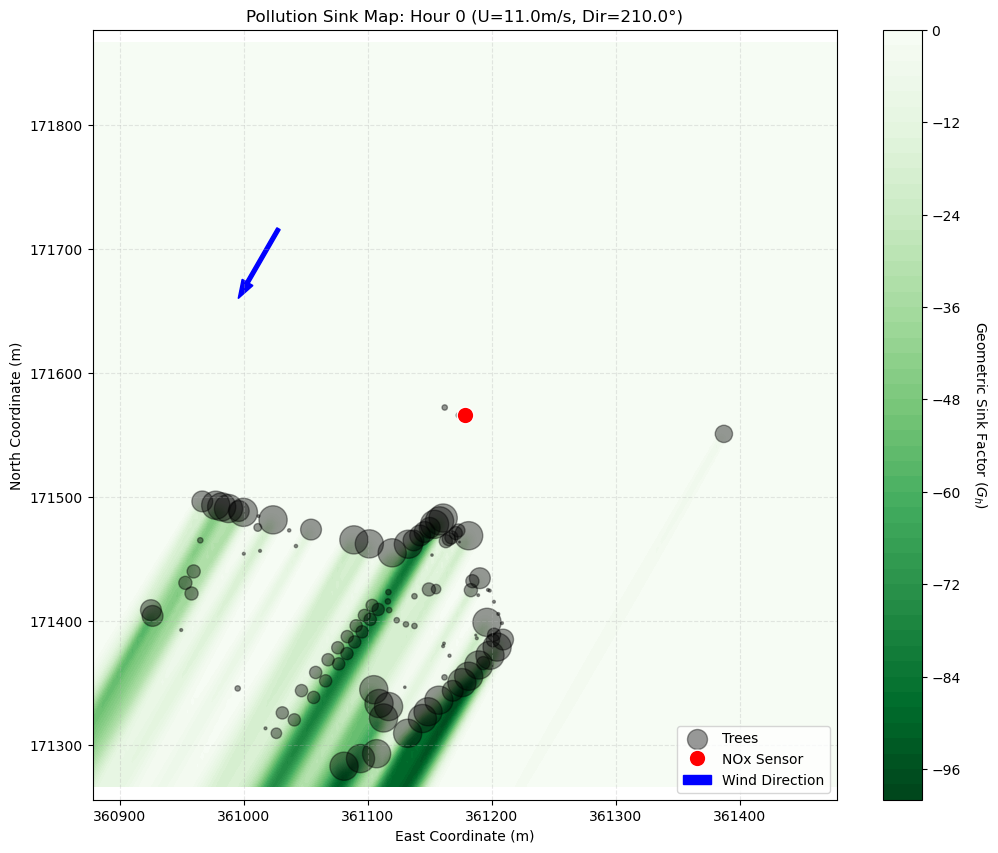

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hourly_wakes(hour_index, wind_df, tree_df, sensor_x, sensor_y):
    """
    Generates a map for a single hour's wind conditions using 3D broadcasting.
    """
    # 1. Extract Wind Data for the chosen hour
    row = wind_df.iloc[hour_index]
    U = row.mean_wind_speed
    direction = row.mean_wind_dir
    
    # 2. Setup the Spatial Grid (300m radius around sensor)
    # Increase resolution (e.g., 300) for smoother plots, decrease for speed
    resolution = 150 
    x_range = np.linspace(sensor_x - 300, sensor_x + 300, resolution)
    y_range = np.linspace(sensor_y - 300, sensor_y + 300, resolution)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    
    # Add 3rd dimension for time broadcasting (Y, X, T)
    X_3d = X_grid[..., np.newaxis]
    Y_3d = Y_grid[..., np.newaxis]
    
    # 3. Physics & Continuity Parameters
    D = 0.2
    T_max = 900
    dt = 1.0 if U <= 1.0 else 1.0 / U
    # Only calculate puffs that stay within the map bounds
    dynamic_T_max = min(T_max, 400 / U) if U > 0.1 else T_max
    t_array = np.arange(dt, dynamic_T_max + dt, dt)
    
    # 4. Wind Vector Convention
    # Default: Meteorological (0=North, 90=East)
    # If your data is 0=East, swap sin and cos.
    theta = np.radians(direction)
    u_wind = U * np.sin(theta) # East component
    v_wind = U * np.cos(theta) # North component

    G_map = np.zeros_like(X_grid, dtype=float)

    print(f"Generating map for hour index {hour_index}...")
    print(f"Wind Conditions: {U} m/s towards {direction}°")

    # 5. Superposition Loop
    for tree in tree_df.itertuples():
        # Canopy physics
        radius = np.sqrt(tree.CROWN_AREA_COMPLETE / np.pi)
        sigma_0 = radius / 2.15
        
        # Where are the puffs? (Center of each Gaussian over time)
        puff_x = tree.X + (u_wind * t_array)
        puff_y = tree.Y + (v_wind * t_array)
        sigma_t = sigma_0 + (D * t_array)
        
        # Distance squared: (Grid - Puff_Center)^2
        # Broadcasting handles the (Res, Res, 1) - (T) interaction
        dist_sq = (X_3d - puff_x)**2 + (Y_3d - puff_y)**2
        
        # Mass-conserved Gaussian Field
        coeff = (tree.CROWN_VOLUME * dt) / (2 * np.pi * sigma_t**2)
        exponent = np.exp(-dist_sq / (2 * sigma_t**2))
        
        # Sum along time axis (axis=2) and add to map
        G_map += np.sum(coeff * exponent, axis=2)

    # 6. Plotting the Results
    plt.figure(figsize=(12, 10))
    
    # Flip G to negative for visual 'sink' intuition
    contour = plt.contourf(X_grid, Y_grid, -G_map, levels=60, cmap='Greens_r')
    cbar = plt.colorbar(contour)
    cbar.set_label('Geometric Sink Factor ($G_h$)', rotation=270, labelpad=20)
    
    # Plot trees - using crown area to scale marker size
    plt.scatter(tree_df.X, tree_df.Y, s=tree_df.CROWN_AREA_COMPLETE * 1.5, 
                color='black', alpha=0.4, label='Trees')
    
    # Plot Sensor
    plt.plot(sensor_x, sensor_y, 'ro', markersize=12, label='NOx Sensor', markeredgecolor='white')
    
    # Visual Wind Arrow (relative to sensor)
    arrow_len = 50
    plt.arrow(sensor_x - 150, sensor_y + 150, 
              arrow_len * np.sin(theta), arrow_len * np.cos(theta), 
              width=3, head_width=10, color='blue', label='Wind Direction')

    plt.title(f"Pollution Sink Map: Hour {hour_index} (U={U}m/s, Dir={direction}°)")
    plt.xlabel("East Coordinate (m)")
    plt.ylabel("North Coordinate (m)")
    plt.legend(loc='lower right')
    plt.axis('equal')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# --- RUN THE PLOT ---
# Pick any index from your wind_subset
plot_hourly_wakes(hour_index=0, 
                  wind_df=wind_subset, 
                  tree_df=nearby_trees, 
                  sensor_x=SENSOR_X, 
                  sensor_y=SENSOR_Y)